# Reproduce Figure 1
This notebook plots key/value/hidden-state norms for BOS sinks and secondary sinks.

You need two files:
- `sink_detection_info_path`: sink detection results from `./src/hidden_state_base.py`.
- `kv_hidden_states_path`: hooked residual/key/value states from `./src/patch_base.py`.

## Start from scratch

### 1) Generate responses with vLLM
```bash
model_short_name=qwen3-4b-base
CUDA_VISIBLE_DEVICES=0 python3 ./src/run_math_vllm.py \
    --model_short_name $model_short_name \
    --dataset_path ./data/aime24.jsonl \
    --save_path ./outputs/aime24/vllm/output_n_1_qwen3-4b-base.jsonl \
    --max_length 16384 \
    --eval_batch_size 1 \
    --n_gen 1 \
    --temperature 0 \
    --use_chat_template
```

### 2) Detect secondary sinks from hidden states
```bash
model_short_name=qwen3-4b-base
python3 ./src/hidden_state_base.py \
    --model_short_name $model_short_name \
    --file_path ./outputs/aime24/vllm/output_n_1_qwen3-4b-base.jsonl \
    --output_dir ./results/sink_detection \
    --gpu_id 0 \
    --sample_num 30 \
    --use_chat_template
```

Output file:
```text
./results/sink_detection/<model_short_name>/sink_detection_<model_short_name>_use_chat_template.jsonl
```

### 3) Collect hidden states with hooks
```bash
model_short_name=qwen3-4b-base
sample_index=4  # choose any sample index from the 30 detected samples
            # (pick one that contains a secondary sink)

python3 ./src/patch_base.py \
    --model_short_name $model_short_name \
    --file_path ./outputs/aime24/vllm/output_n_1_qwen3-4b-base.jsonl \
    --output_dir ./results/sink_detection \
    --gpu_id 0 \
    --sample_index $sample_index \
    --collector_targets residual k v \
    --use_chat_template
```

Output file:
```text
./results/sink_detection/<model_short_name>/residual-k-v_layer_all_<model_short_name>_chat_template_sample<sample_index>.pt
```

In [ ]:
import os
from pathlib import Path
from src.utils import MODEL_DICT
import torch
import json
import matplotlib.pyplot as plt
import numpy as np
import os

model_short_code = "qwen3-4b-base"
sink_detection_info_path = Path(f"./results/sink_detection/{model_short_code}/sink_detection_{model_short_code}_use_chat_template.jsonl")
kv_hidden_states_path = Path(f"./results/sink_detection/{model_short_code}/residual-k-v_layer_all_{model_short_code}_chat_template_sample4.pt")


In [4]:
sample_index = (
        str(kv_hidden_states_path)
        .split("_")[-1]
        .replace(".pt", "")
        .replace("sample", "")
    )
model_name = MODEL_DICT[model_short_code]

# --- Load tensors ---
kv_hidden_states = torch.load(kv_hidden_states_path, weights_only=False)
print("Loaded kv_hidden_states from:", kv_hidden_states_path)

# --- Load sink detection info ---
with open(sink_detection_info_path, "r") as f:
    lines = [json.loads(line) for line in f.readlines()]

sink_info = next(
    (line for line in lines if line["sample_index"] == int(sample_index)),
    None,
)
if sink_info is None:
    raise ValueError(f"Sample index {sample_index} not found in sink info file")

candidate_sinks = sink_info["candidate_sinks"]

# --- Separate secondarys and sinks ---
secondary_list = []
sink_list = []
for position, info in candidate_sinks.items():
    sink_type = info["sink_type"]
    if sink_type == "secondary":
        secondary_list.append(int(position))
    elif sink_type == "bos_sink":
        sink_list.append(int(position))

print("Model short code:", model_short_code, "sample_index:", sample_index)

Loaded kv_hidden_states from: results/sink_detection/qwen3-4b-base/residual-k-v_layer_all_qwen3-4b-base_chat_template_sample4.pt
Model short code: qwen3-4b-base sample_index: 4


In [5]:
kv_hidden_states.keys(), kv_hidden_states[0].keys(), len(kv_hidden_states[0]['k']), kv_hidden_states[0]['k'][0].shape


k = torch.stack([kv_hidden_states[layer]["k"][0] 
                 for layer in sorted(kv_hidden_states.keys())])
k.shape  # (num_layers, seq_len, hidden_dim)

hidden_states = torch.stack([kv_hidden_states[layer]["residual"][0] 
                            for layer in sorted(kv_hidden_states.keys())]).squeeze()  # (num_layers, seq_len, hidden_dim)
hidden_states.shape

torch.Size([36, 16509, 2560])

Saved plot to: results/sink_detection/qwen3-4b-base/k_v_hidden_states_norm_qwen3-4b-base_4.pdf


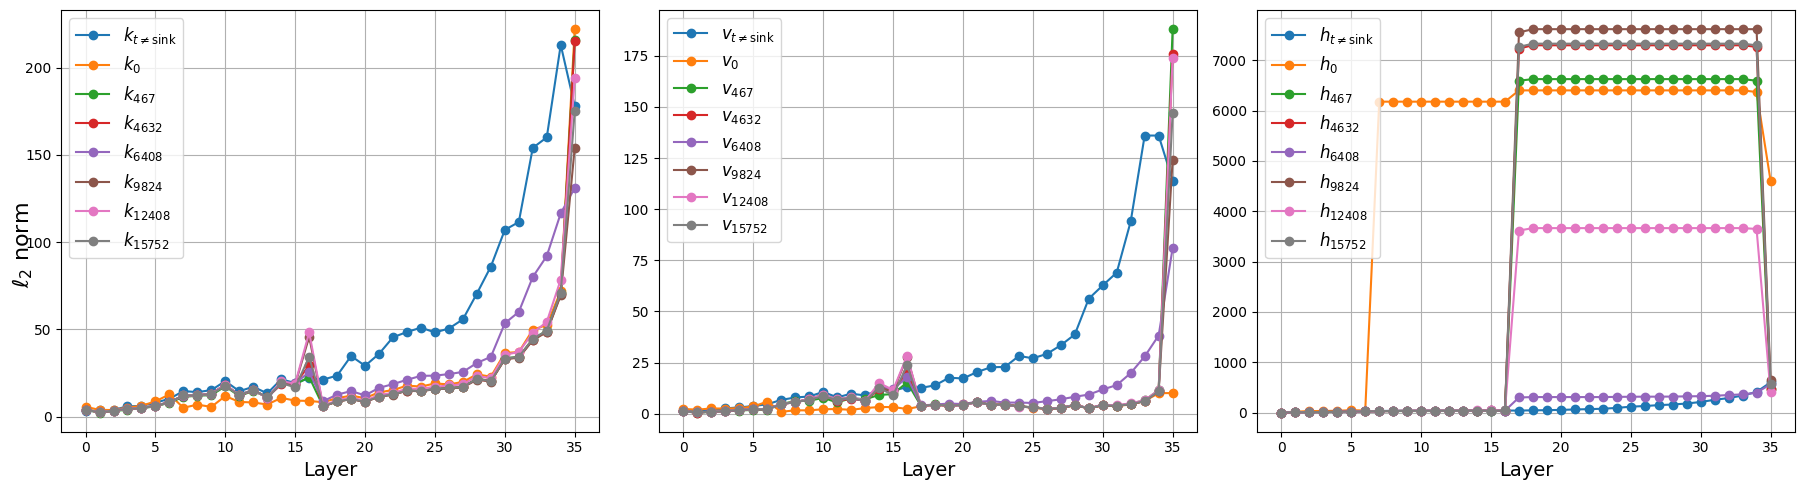

In [7]:
# --- Stack tensors ---

from pathlib import Path


k = torch.stack([kv_hidden_states[layer]["k"][0] 
                for layer in sorted(kv_hidden_states.keys())])
v = torch.stack([kv_hidden_states[layer]["v"][0] 
                for layer in sorted(kv_hidden_states.keys())])
hidden_states = torch.stack([kv_hidden_states[layer]["residual"][0]
                for layer in sorted(kv_hidden_states.keys())]).squeeze()  # (num_layers, seq_len, hidden_dim)

# --- Initialize storage ---
rest_key_norm_list = []
rest_value_norm_list = []
rest_hidden_states_norm_list = []

sink_key_norm_list = {idx: [] for idx in sink_list}
sink_value_norm_list = {idx: [] for idx in sink_list}
sink_hidden_states_norm_list = {idx: [] for idx in sink_list}

secondary_key_norm_list = {idx: [] for idx in secondary_list}
secondary_value_norm_list = {idx: [] for idx in secondary_list}
secondary_hidden_states_norm_list = {idx: [] for idx in secondary_list}

# --- Compute norms layer by layer ---
for l in range(len(hidden_states)):
    layer_k = k[l]
    layer_v = v[l]
    layer_hs = hidden_states[l]

    # Compute per-token norms
    layer_k_norms = torch.norm(layer_k, dim=1)
    layer_v_norms = torch.norm(layer_v, dim=1)
    layer_hs_norms = torch.norm(layer_hs, dim=1)

    # Compute rest positions (not in sinks/secondarys)
    rest_positions = [
        i for i in range(layer_k.size(0)) if str(i) not in candidate_sinks
    ]
    rest_key_norm = layer_k_norms[rest_positions].mean()
    rest_value_norm = layer_v_norms[rest_positions].mean()
    rest_hidden_states_norm = layer_hs_norms[rest_positions].mean()

    rest_key_norm_list.append(rest_key_norm)
    rest_value_norm_list.append(rest_value_norm)
    rest_hidden_states_norm_list.append(rest_hidden_states_norm)

    # Collect norms for sink tokens
    for idx in sink_list:
        sink_key_norm_list[idx].append(layer_k_norms[idx])
        sink_value_norm_list[idx].append(layer_v_norms[idx])
        sink_hidden_states_norm_list[idx].append(layer_hs_norms[idx])

    # Collect norms for secondary tokens
    for idx in secondary_list:
        secondary_key_norm_list[idx].append(layer_k_norms[idx])
        secondary_value_norm_list[idx].append(layer_v_norms[idx])
        secondary_hidden_states_norm_list[idx].append(layer_hs_norms[idx])

# --- Convert lists to tensors ---
rest_key_norm_list = torch.stack(rest_key_norm_list)
rest_value_norm_list = torch.stack(rest_value_norm_list)
rest_hidden_states_norm_list = torch.stack(rest_hidden_states_norm_list)

for d in [sink_key_norm_list, sink_value_norm_list, sink_hidden_states_norm_list]:
    for idx in d:
        d[idx] = torch.stack(d[idx])

for d in [secondary_key_norm_list, secondary_value_norm_list, secondary_hidden_states_norm_list]:
    for idx in d:
        d[idx] = torch.stack(d[idx])

# --- Helper for plotting ---
def to_cpu_numpy(t):
    return t.to(torch.float32).cpu().numpy()

# --- Plotting ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

titles = [
    "Average over head: Key Norms Across Layers",
    "Average over head: Value Norms Across Layers",
    "Average over head: Hidden State Norms Across Layers",
]

plot_data = [
    (rest_key_norm_list, sink_key_norm_list, secondary_key_norm_list, "Key Norm"),
    (rest_value_norm_list, sink_value_norm_list, secondary_value_norm_list, "Value Norm"),
    (rest_hidden_states_norm_list, sink_hidden_states_norm_list, secondary_hidden_states_norm_list, "Hidden States Norm"),
]


for ax, (rest, sink_dict, secondary_dict, label_base), title in zip(axes, plot_data, titles):

    if label_base == "Hidden States Norm":
        ax.plot(to_cpu_numpy(rest), label=r"$h_{t \ne \text{sink}}$", marker="o")
        for idx in sink_dict:
            ax.plot(to_cpu_numpy(sink_dict[idx]), label=fr"$h_{{{idx}}}$", marker="o")
        for idx in secondary_dict:
            ax.plot(to_cpu_numpy(secondary_dict[idx]), label=fr"$h_{{{idx}}}$", marker="o")
    elif label_base == "Key Norm":
        ax.plot(to_cpu_numpy(rest), label=r"$k_{t \ne \text{sink}}$", marker="o")
        for idx in sink_dict:
            ax.plot(to_cpu_numpy(sink_dict[idx]), label=fr"$k_{{{idx}}}$", marker="o")
        for idx in secondary_dict:
            ax.plot(to_cpu_numpy(secondary_dict[idx]), label=fr"$k_{{{idx}}}$", marker="o")
    elif label_base == "Value Norm":
        ax.plot(to_cpu_numpy(rest), label=r"$v_{t \ne \text{sink}}$", marker="o")
        for idx in sink_dict:
            ax.plot(to_cpu_numpy(sink_dict[idx]), label=fr"$v_{{{idx}}}$", marker="o")
        for idx in secondary_dict:
            ax.plot(to_cpu_numpy(secondary_dict[idx]), label=fr"$v_{{{idx}}}$", marker="o")

    ax.set_xlabel("Layer", fontsize=14)
    # ax.set_title(title)
    ax.legend(fontsize=12)
    ax.grid(True)

# Shared Y label
fig.text(0.0, 0.5, r"$\ell_2\ \text{norm}$", va="center", rotation="vertical", fontsize=16)


plt.tight_layout()
# basedir
basedir = Path(kv_hidden_states_path).parent
os.makedirs(basedir, exist_ok=True)
save_path = basedir / f"k_v_hidden_states_norm_{model_short_code}_{sample_index}.pdf"   
plt.savefig(save_path, format="pdf", dpi=300, bbox_inches="tight")
print(f"Saved plot to: {save_path}")
plt.show()